 # DSA Patterns for Interview Questions

### Control Flow and Looping
    - for i in range(n)
    - for val in arr
    - while start < end
    - if, else, etif
    - break continue

### Time Complexity

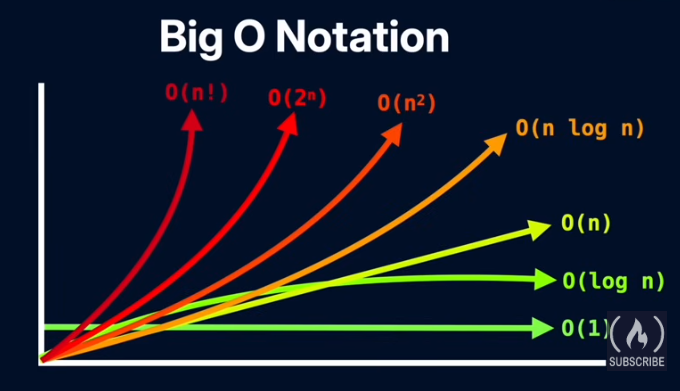

1. O(1) - *Constant Time* accessing a element in arr, checking if an ele exits
2. O(log n) - *Logarithmic Time* dividing the problem by half each time; Binary Search
3. O(n) - *Linear Time* Going through each element atleast once; loops and traversing through lists
4. O(n log n) - sorting
5. O(n^2) - *Quadratic Time* Brute force comparisons; too slow for large inputs

 - Fastest to Slowest : O(1) > O(log n) > O(n) > O(n log n) > O(n^2) > O(2^n) > O(n!)
 - for inputs up to 10^5 --> O(n log n) or better
 - for inputs up to 10^4 --> O(n^2) *{can be tolerated}*
---

## Hash Functions

For each value : key given to --> Hash Function --> gives a number(*Hash*) that points to a loc in memory
- Very Fast - since they don't depend on size of data(10 or 10million) - getting and setting data takes same amount of time
- *Collision* - when 2 values get same the Hash
- Rule for key -> should be *Hashable* : 
    - Hashable - Numbers, Strings, Tuples(Immutable)
    - Non Hashable - Lists, Dictionaries
- Very commonly asked in interviews -> go to method when brute force takes too long
    - when finding value exists : No hashmap - O(n); Hashmap - O(1)
- Commonly used in :  
    - Storing something
    - Looking something up
    - Updating/initializing values

- Common Structure:  
    `my_map = {}               `  
    
    `for item in data:         `  
    `   if item not in my_map: `  
    `       my_map [item] = 1  `  
    `   else:                  `   
    `       my_map [item] += 1 `  
    
    - This structure is called a Frequency map


In [9]:
#Interview Question : Two Sum 
# Given an array of integers nums and an integer target return the indices of the two numbers such that they add up to target You may assume that each input would have exactly one solution and you may not use the same element
def twoSum(arr, target):
    nums = {}
    for i, x in enumerate(arr):
        complement = target - x
        if complement in nums.keys():
            return [nums[complement], i]
        nums[x] = i
    return []

print(twoSum([100, 1000, 2001, 3000, 4000, 5000], 5001))

[2, 3]


## Two Pointers

For problems involving linear structures like - Arrays, Strings, Linked lists etc

- 2 indices/pointes -> 1 for tracking the *Start* and other for tracking the *End*
- One common use case -> *Fast & Slow Pointers* :  
  - Fast - moves two places at once  
  - Slow - moves 1 place at a time
    1. When fast reaches end or one place before the end of a linear structure, the postion of slow pointer gives the mid point
    2. When fast and slow pointers meet it indicates loop
- Advantages :
    - Reduce the number of iterations you need
    - Track a relationship between two places
    - Avoid extra space
- Palindromes; Reversals; Merging sorted data; K sized comparisons

In [23]:
# Valid Palindrome
# Given a string s, determine if it is a palindrome, considering only alphanumeric characters and ignoring cases.
def validPalindrome(str_in):
    if(len(str_in.strip()) == 0):
        return False
        
    string = str_in.lower()
    left = 0
    right = len(string) - 1
    
    while(left < right):
        if(not(string[left].isalnum()) or not(string[right].isalnum())):
            continue
        if(string[left] == string[right]):
            left += 1
            right -= 1
        else :
            return False
    return True

print(validPalindrome("racecar"))
print(validPalindrome("sheetal"))
print(validPalindrome(" "))

True
False
False


In [8]:
# Middle of a Linked List
# Find the middle node Of a linked list.
class Node:
    def __init__(self, data):
        self.data = data
        self.next = None

def insertNode(head, data):
    if head == None:
        head = Node(data)
        return head
    temp = head
    while(temp.next != None):
        temp = temp.next
    temp.next = Node(data)
    return head

def displayList(head):
    temp = head
    while(temp.next != None):
        print(temp.data, end = " -> ")
        temp = temp.next
    print(temp.data)
    

def findMid(head):
    fast = head
    slow = head
    while(fast != None and fast.next != None):
        fast = fast.next.next
        slow = slow.next

    return slow.data

head = None
head = insertNode(head, 1)
head = insertNode(head, 2)
head = insertNode(head, 3)
head = insertNode(head, 4)
head = insertNode(head, 5)
displayList(head)
res = findMid(head)
print(res)

1 -> 2 -> 3 -> 4 -> 5
3


## Sliding Window
Dynamic Window
 - Find the length of the longest substring with at most K unique characters; What's the smallest subarray with a sum greater than a target?; Return the longest window where a certain rule is valid.

- Expand the window size according to req size.
- if condition fails - reduce size from the left until condition satisfies again
- Common algorithm:  
    `def sliding_window_flexible_tongest(input):`  
    `    initialize window, ans`  
    `    left = 0`  
    `    for right in range(len(input)):`  
    `        append input[right] to window`  
    `        while invalid(window):`  
    `            remove input[left] from window`  
    `            left += 1`  
    `        ans = max(ans, window)`  
    `    return ans`  

In [30]:
# Subarray sum (Fixed Size Sliding Window)
# Given an array (list) nuns consisted of only non-negative integers, find the largest sum among all subarrays Of length k nums.

def subarray_sum(arr, k):
    left = 0
    right = k - 1

    max_sum = 0
    while right < len(arr):
        max_sum = max(max_sum, sum(arr[left : right + 1]))
        print(arr[left : right + 1], max_sum)
        right += 1
        left += 1
    return max_sum

print(subarray_sum([1, 2, 3, 7, 4, 1], 3))

#actual implementation - video
def subarray_sum_fixed(nums, k):
    window_sum = 0
    
    for i in range(k):
        window_sum += nums[i]
    largest = window_sum
        
    for right in range(k, len(nums)):
        left = right - k
        window_sum -= nums[left]
        window_sum += nums[right]
        largest = max(largest, window_sum)
    return largest
    
print(subarray_sum_fixed([1, 2, 3, 7, 4, 1], 3))

[1, 2, 3] 6
[2, 3, 7] 12
[3, 7, 4] 14
[7, 4, 1] 14
14
14


In [35]:
#Longest Substring without Repeating Characters
#Find the length of the largest substring of a given string without repeating characters.
def longest_substring(string):
    left = 0
    max_len = 0
    chars = set()
    for right in range(len(string)):
        while string[right] in chars:
            left += 1
            chars.remove(string[left])
        chars.add(string[right])
        max_len = max(max_len, right - left + 1)

    return max_len

longest_substring("abccabcabcc")

3

## Binary Search
- Time Complexity - O(log n)  
    `def binary_search(arr, target):`  
    `    left, right = 0, len(arr) - 1`  
    `    mid = (left + right) // 2`  
    `    while left <= right: `   
    `       if mid == target`  
    `          return mid`  
    `       elif mid < target`  
    `          left = mid + 1`  
    `       elif mid > target`  
    `          right = mid - 1`  
    `     return -1`

- usually for sorted arrays, but is really useful for monotonic serieses also

In [42]:
# Find the First True in a Sorted Boolean Array
#An array Of boolean Oues is divided into two sections: The left section consists Of all False, and the right section consists of all True, 
# Find the First True a Sorted Boolean Array ot the right section. i.e. the index of the first true If there is no True element, return -1.

def find_first_true(arr):
    left = 0
    right = len(arr) - 1
    result = -2
    
    while left <= right:
        mid = (left + right) // 2
        
        if arr[mid] == True:
            result = mid
            right = mid - 1 
        else:
            left = mid + 1 
            
    return result + 1

print(find_first_true([False, False, False, False, False, False, False, True, True, True, True, True, True, True]))
        

8
